In [1]:
from autocvd import autocvd
autocvd(num_gpus = 1, interval=1)
# import os
# os.environ['CUDA_VISIBLE_DEVICES'] = '5'

import numpy as np
import matplotlib.pyplot as plt
import time 
from functools import partial  # Change this line - lowercase 'partial'

import jax.numpy as jnp
import jax
from jax import jit

# jax.config.update("jax_enable_x64", True)
from jax.sharding import Mesh, PartitionSpec, NamedSharding         #IMPORT NEEDED FOR AUTOMATIC PARALLELISM
from jax.experimental import shard_map



import pandas as pd
import seaborn as sns
from chainconsumer import Chain, ChainConsumer, Truth
from jax.scipy.special import logsumexp



from odisseo import construct_initial_state
from odisseo.dynamics import  DIRECT_ACC_MATRIX, DIRECT_ACC_LAXMAP
from odisseo.option_classes import SimulationConfig, SimulationParams, MNParams, NFWParams, PlummerParams, PSPParams, MN_POTENTIAL, NFW_POTENTIAL, PSP_POTENTIAL, DIFFRAX_BACKEND, TSIT5
from odisseo.initial_condition import Plummer_sphere
from odisseo.time_integration import time_integration
from odisseo.units import CodeUnits
from odisseo.utils import projection_on_GD1
from astropy import units as u
import blackjax
from tqdm import tqdm


code_length = 10.0 * u.kpc
code_mass = 1e4 * u.Msun
code_time = 3 * u.Gyr
code_units = CodeUnits(code_length, code_mass, G=1, unit_time = code_time )  
N_particles = 1000

pos_com_final = jnp.array([[11.8, 0.79, 6.4]]) * u.kpc.to(code_units.code_length)
vel_com_final = jnp.array([[109.5,-254.5,-90.3]]) * (u.km/u.s).to(code_units.code_velocity)
config_sim = SimulationConfig(N_particles = N_particles,
                            return_snapshots = False, 
                            num_timesteps = 1000, 
                            external_accelerations=(NFW_POTENTIAL, MN_POTENTIAL, PSP_POTENTIAL), 
                            acceleration_scheme = DIRECT_ACC_MATRIX,
                            softening = (0.1 * u.pc).to(code_units.code_length).value,
                             integrator = DIFFRAX_BACKEND,
                             fixed_timestep = False,
                             diffrax_solver = TSIT5,
                            ) #default values
        #the center of mass needs to be integrated backwards in time first 
config_com = config_sim._replace(N_particles=1,)

@jit
def run_simulation(rng_key, params):
    params_samples = SimulationParams(t_end = params['t_end'] * u.Gyr.to(code_units.code_time),
                        Plummer_params = PlummerParams(Mtot=params['Mtot'] * u.Msun.to(code_units.code_mass),
                                                       a = params['a_Plummer'] * u.kpc.to(code_units.code_length),),
                        NFW_params = NFWParams(Mvir=params['M_NFW'] * u.Msun.to(code_units.code_mass),
                                               r_s= params['r_s'] * u.kpc.to(code_units.code_length)),
                        MN_params = MNParams(M = params['M_MN'] * u.Msun.to(code_units.code_mass),
                                             a = params['a_MN'] * u.kpc.to(code_units.code_length),
                                            b = (0.280 * u.kpc).to(code_units.code_length).value),
                        PSP_params= PSPParams(M = 4501365375.06545 * u.Msun.to(code_units.code_mass),
                                                alpha = 1.8, 
                                                r_c = (1.9*u.kpc).to(code_units.code_length).value),  
                        G = code_units.G, )

    params_com = params_samples._replace(t_end=-params_samples.t_end,)
    mass_com = jnp.array([params_samples.Plummer_params.Mtot]) 
    
    #we construmt the initial state of the com 
    initial_state_com = construct_initial_state(pos_com_final, vel_com_final,)
    #we run the simulation backwards in time for the center of mass
    final_state_com = time_integration(initial_state_com, mass_com, config=config_com, params=params_com)
    #we calculate the final position and velocity of the center of mass
    pos_com = final_state_com[:, 0]
    vel_com = final_state_com[:, 1]

    #we construct the initial state of the Plummer sphere
    positions, velocities, mass = Plummer_sphere(key=rng_key, params=params_samples, config=config_sim)
    #we add the center of mass position and velocity to the Plummer sphere particles
    positions = positions + pos_com
    velocities = velocities + vel_com
    #initialize the initial state
    initial_state_stream = construct_initial_state(positions, velocities, )
    #run the simulation
    final_state = time_integration(initial_state_stream, mass, config=config_sim, params=params_samples)

    #projection on the GD1 stream
    stream = projection_on_GD1(final_state, code_units=code_units,)

    return stream


# Utility: ensure non-neg and avoid zeros
@jit
def _safe(d, eps=1e-12):
    return jnp.clip(d, a_min=eps)


@jit
def loss_js(d_target, d_sim):
    p = _safe(d_target) / jnp.sum(_safe(d_target))
    q = _safe(d_sim)   / jnp.sum(_safe(d_sim))
    m = 0.5 * (p + q)
    return 0.5 * (jnp.sum(p * (jnp.log(p) - jnp.log(m))) + jnp.sum(q * (jnp.log(q) - jnp.log(m))))

@jit
def cross_entropy(d_target, d_sim):
    p = _safe(d_target) / jnp.sum(_safe(d_target))
    q = _safe(d_sim)   / jnp.sum(_safe(d_sim))
    # cross-entropy
    return -jnp.sum(p * jnp.log(q))

# Define bin edges and create meshgrids
phi1_bins = jnp.linspace(-120, 70, 65)    # 64 bins
phi2_bins = jnp.linspace(-8, 2, 33)       # 32 bins
v1_bins = jnp.linspace(-2., 1.0, 65)      # 64 bins  
v2_bins = jnp.linspace(-0.10, 0.10, 33)   # 32 bins
R_bins = jnp.linspace(6, 20, 65)          # 64 bins
vR_bins = jnp.linspace(-250, 250, 33)     # 32 bins


# Create meshgrids for bin edges (not centers)
PHI1, PHI2 = jnp.meshgrid(phi1_bins, phi2_bins, indexing='ij')
V1, V2 = jnp.meshgrid(v1_bins, v2_bins, indexing='ij')
R_GRID, VR_GRID = jnp.meshgrid(R_bins, vR_bins, indexing='ij')


@jit
def kde2d_on_grid(x, grid_x, grid_y, bandwidth):
    """
    Evaluate 2D Gaussian KDE on a meshgrid.
    """
    N, d = x.shape
    assert d == 2

    # Flatten grid to (G, 2)
    grid_points = jnp.stack([grid_x.ravel(), grid_y.ravel()], axis=1)  # (G,2)

    # Differences (G, N, 2)
    diff = grid_points[:, None, :] - x[None, :, :]

    # Bandwidth handling
    bw = jnp.atleast_1d(bandwidth)
    if bw.shape == (1,):
        bw = jnp.repeat(bw, 2)
    var = bw**2

    # Mahalanobis distance
    sq = (diff**2) / var  # (G,N,2)

    # log kernel for each (gridpoint, datapoint)
    logk = -0.5 * jnp.sum(sq, axis=-1) - 0.5*jnp.sum(jnp.log(2*jnp.pi*var))

    # logsumexp over datapoints
    log_dens = logsumexp(logk, axis=1) - jnp.log(N)

    return jnp.exp(log_dens).reshape(grid_x.shape)


@jit
def densities(stream):
    # take relevant projections from simulated stream
    xs = jnp.array([
        stream[:, [1, 2]],  # phi
        stream[:, [4, 5]],  # v
        stream[:, [0, 3]],  # R
    ])
    grids = jnp.array([
        [PHI1, PHI2],
        [V1, V2],
        [R_GRID, VR_GRID],
    ])
    bws = jnp.array([
        [2.0, 0.5],   # phi
        [0.1, 0.01],  # v
        [0.5, 20.0],  # R
    ])

    # vmap over the 3 projections
    dens_all = jax.vmap(
        lambda x, grid, bw: kde2d_on_grid(x, grid[0], grid[1], bw)
    )(xs, grids, bws)

    # unpack densities
    dens_phi, dens_v, dens_R = dens_all
    return dens_phi, dens_v, dens_R

@jit
def stream_likelihood(model_stream, ):
    
    dens_phi, dens_v, dens_R = densities(model_stream)


    return jnp.exp(- 0.1 * (
            loss_js(dens_phi_target, dens_phi) 
            +
            loss_js(dens_v_target, dens_v) 
            + 
            loss_js(dens_R_target, dens_R)
            )
            )


true_GD1_observation_path = '/export/data/vgiusepp/odisseo_data/data_fix_position/true.npz'
observation = jnp.array(np.load(true_GD1_observation_path)['x']).reshape(1000, 6)
true_theta = jnp.array(np.load(true_GD1_observation_path)['theta'])

# ----------------------------- Load observation & precompute target densities ----------------
true_GD1_observation_path = '/export/data/vgiusepp/odisseo_data/data_fix_position/true.npz'
_obs = np.load(true_GD1_observation_path)
observation = jnp.array(_obs['x']).reshape(1000, 6)  # will be used only to compute target densities
true_theta = jnp.array(_obs['theta'])

# Precompute the target densities ONCE (expensive step)
dens_phi_target, dens_v_target, dens_R_target = densities(observation)


@jit
def evaluate_loglikelihood(theta_1, ):

        key = jax.random.PRNGKey(0)
        # print(f"In the corrector: theta_1 shape: {theta_1.shape}, target shape: {target.shape}")
        output = run_simulation(key, theta_1)

        # return stream_likelihood(model_stream=output, obs_stream=observation, obs_errors=jnp.array([0.25, 0.001, 0.15, 5., 0.1, 0.0001]))
        return jnp.log(stream_likelihood(model_stream=output, ))

# True parameter values (without code_units transformation)
true_params = jnp.array([
    3.0,                    # t_end (Gyr)
    10**4.05,              # Plummer Mtot (Msun) 
    8.0 * 1e-3,            # Plummer a (kpc) - converted from pc to kpc
    4.3683325e11,          # NFW Mvir (Msun)
    16.0,                  # NFW r_s (kpc)
    68_193_902_782.346756, # MN M (Msun)
    3.0,                   # MN a (kpc)
])

# Prior bounds for each parameter
prior_bounds = jnp.array([
    [0.5, 5.0],                    # t_end: 0.5 to 5 Gyr
    [10**3, 10**4.5],              # Plummer Mtot: 10^3 to 10^4.5 Msun
    [8.0 * 1e-3 * 0.25, 8.0 * 1e-3 * 2.0],  # Plummer a: 1/4 to 2x true (kpc)
    [4.3683325e11 * 0.25, 4.3683325e11 * 2.0],  # NFW Mvir: 1/4 to 2x true
    [16.0 * 0.25, 16.0 * 2.0],    # NFW r_s: 1/4 to 2x true (kpc)
    [68_193_902_782.346756 * 0.25, 68_193_902_782.346756 * 2.0],  # MN M: 1/4 to 2x true
    [3.0 * 0.25, 3.0 * 2.0],      # MN a: 1/4 to 2x true (kpc)
])  # Shape: (7, 2) for [min, max] bounds

def draw_from_prior(key):
    """Draw samples from uniform prior."""
    key, subkey = jax.random.split(key)
    u = jax.random.uniform(subkey, shape=(7,))
    
    # Transform uniform [0,1] to [min, max] for each parameter
    samples = prior_bounds[:, 0] + u * (prior_bounds[:, 1] - prior_bounds[:, 0])
    samples = {'t_end': samples[0], 'Mtot': samples[1], 'a_Plummer': samples[2], 'M_NFW': samples[3], 'r_s': samples[4], 'M_MN': samples[5], 'a_MN': samples[6]}
    return samples

param_order = ['t_end', 'Mtot', 'a_Plummer', 'M_NFW', 'r_s', 'M_MN', 'a_MN']
@jit
def dict_to_array(theta_dict):
    return jnp.array([theta_dict[k] for k in param_order])

@jit
def array_to_dict(theta_array):
    return {k: theta_array[i] for i, k in enumerate(param_order)}

@jit
def evaluate_log_prior(theta):
    """Evaluate log prior density (uniform)."""
    # Check if all parameters are within bounds 
    # theta = jnp.array([theta['t_end'], theta['Mtot'], theta['a_Plummer'], theta['M_NFW'], theta['r_s'], theta['M_MN'], theta['a_MN']])
    # in_bounds = jnp.all((theta >= prior_bounds[:, 0]) & (theta <= prior_bounds[:, 1])) 
    in_bounds = jnp.all(jnp.array([
        (theta['t_end'] >= prior_bounds[0, 0]) & (theta['t_end'] <= prior_bounds[0, 1]),
        (theta['Mtot'] >= prior_bounds[1, 0]) & (theta['Mtot'] <= prior_bounds[1, 1]),
        (theta['a_Plummer'] >= prior_bounds[2, 0]) & (theta['a_Plummer'] <= prior_bounds[2, 1]),    
        (theta['M_NFW'] >= prior_bounds[3, 0]) & (theta['M_NFW'] <= prior_bounds[3, 1]),
        (theta['r_s'] >= prior_bounds[4, 0]) & (theta['r_s'] <= prior_bounds[4, 1]),
        (theta['M_MN'] >= prior_bounds[5, 0]) & (theta['M_MN'] <= prior_bounds[5, 1]),
        (theta['a_MN'] >= prior_bounds[6, 0]) & (theta['a_MN'] <= prior_bounds[6, 1]),
    ]))
    
    # For uniform distribution: log(density) = -log(volume)
    # Volume = product of interval widths
    log_volume = jnp.sum(jnp.log(prior_bounds[:, 1] - prior_bounds[:, 0]))
    
    # Return -inf if out of bounds, -log_volume if in bounds
    return jnp.where(in_bounds, -log_volume/10000, -jnp.inf)
    # return -log_volume


def draw_from_proposal(key, theta, sigma2_prop):
    key, sk = jax.random.split(key)
    theta_prime = jax.random.normal(sk, shape=theta.shape) * jnp.sqrt(sigma2_prop) + theta
    return theta_prime, key

@jit
def evaluate_log_posterior_grad(theta):
    """Compute gradient of log posterior."""
    
    def log_posterior(theta):
        log_prior = evaluate_log_prior(theta)
        log_like = evaluate_loglikelihood(theta)
        return log_prior + log_like
    
    # Get both value and gradient
    log_post_val, grad = jax.value_and_grad(log_posterior)(theta)
    return log_post_val, grad

@jit
def evaluate_log_posterior(theta):
    log_prior = evaluate_log_prior(theta)
    log_like = evaluate_loglikelihood(theta_1 = theta, )
    return log_prior + log_like

# NUTS

In [2]:

# Scale-aware mass matrix based on parameter magnitudes
param_scales = jnp.array([
    1.0,        # t_end (Gyr) - order 1
    1e4,        # Mtot (Msun) - order 10^4
    1e-3,       # a_Plummer (kpc) - order 10^-3
    1e11,       # M_NFW (Msun) - order 10^11
    10.0,       # r_s (kpc) - order 10
    1e11,       # M_MN (Msun) - order 10^11
    1.0,        # a_MN (kpc) - order 1
])

# Create inverse mass matrix with scale-appropriate variances
scale_factors = 0.01 * param_scales  # 1% of typical scale as step size
inverse_mass_matrix = jnp.diag(scale_factors**2)
# # Build the kernel
step_size = 1e-3



# nuts = blackjax.nuts(evaluate_log_posterior, step_size, inverse_mass_matrix)

# Initialize the state
posterior_SBI = np.load('../logs/OdisseoCrossAttentionSetTransformer_small_AllParameters_Position_uniforprior_2e5_TSIT5/pictures/predicted_theta_test_set.npz')['predicted_theta'][0]
init_positions = np.mean(posterior_SBI, axis=0)
init_positions = array_to_dict(init_positions)
init_positions['M_NFW'] = 10**init_positions['M_NFW']
init_positions['M_MN'] = 10**init_positions['M_MN']
init_positions['Mtot'] = 10**init_positions['Mtot']

warmup = blackjax.window_adaptation(blackjax.nuts, evaluate_log_posterior, progress_bar=True)

rng_key = jax.random.PRNGKey(0)
rng_key, warmup_key, sample_key = jax.random.split(rng_key, 3)
(state, parameters), _ = warmup.run(warmup_key, init_positions, num_steps=20)

nuts = blackjax.nuts(evaluate_log_posterior, **parameters)

from blackjax.util import run_inference_algorithm

final_state, history_state = run_inference_algorithm(
    rng_key=jax.random.PRNGKey(0),
    inference_algorithm=nuts,
    num_steps=100,
    initial_state=state,
    progress_bar=True,
)

Running window adaptation


In [16]:
history_state[1]

NUTSInfo(momentum={'M_MN': Array([ -36.352287  ,   12.58001   ,  -93.88189   ,  106.367744  ,
         54.742893  ,    1.845225  ,  -65.37833   ,  -37.274403  ,
        107.91067   ,  -60.608154  ,   35.370255  ,   35.472393  ,
        -56.71002   ,  -62.09833   ,  -39.354748  ,  -12.200078  ,
        -14.130593  ,  -68.80675   ,   13.408929  ,   54.45899   ,
         90.939964  ,  -47.563896  ,   61.319027  , -102.99731   ,
        -53.74172   ,  -17.71792   ,   -7.4528117 ,   -4.6937084 ,
        -10.1794815 ,   29.441277  ,  -52.94023   ,  -50.70211   ,
        -40.114174  ,  -77.75141   ,  -56.183617  , -112.65013   ,
        -60.46378   ,   73.61979   ,  -29.741764  ,  -26.625645  ,
        -13.687357  ,    6.207891  ,  -21.399101  ,  -45.158276  ,
         42.16935   ,  -79.41022   ,   72.60047   ,   43.838226  ,
         47.658195  ,   43.23652   ,    8.64286   ,   75.20146   ,
         -0.41831917,  -60.763824  ,  -32.31732   ,   44.221764  ,
          1.2897546 ,  101.02169   

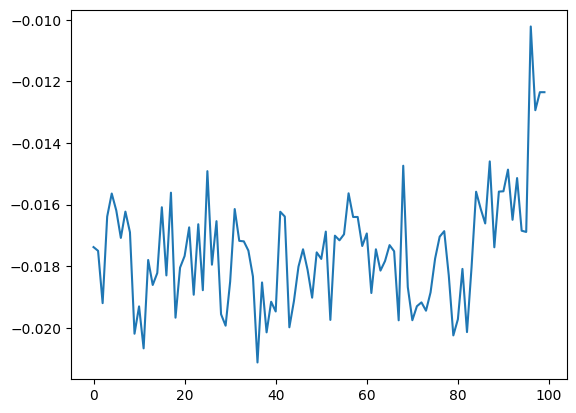

In [4]:
plt.plot(history_state[0].logdensity)

In [8]:
df_burned

,$M_{MN}$ [M$_\odot$],$M_{NFW}$ [M$_\odot$],$M_{Plummer}$ [M$_\odot$],$a_{MN}$ [kpc],$a_{Plummer}$ [kpc],$r_s$ [kpc],$t_{end}$ [Gyr]
0,8.028854e+10,5.314145e+11,17032.958984,3.583111,0.005285,20.608793,2.765333
1,8.028854e+10,5.314145e+11,17032.958984,3.583963,0.006501,20.594736,2.784239
2,8.028854e+10,5.314145e+11,17032.958984,3.588404,0.012915,20.604710,2.790896
3,8.028854e+10,5.314145e+11,17032.958984,3.591811,0.013719,20.603352,2.791389
4,8.028854e+10,5.314145e+11,17032.958984,3.591882,0.014999,20.603565,2.792722
...,...,...,...,...,...,...,...
94,8.028854e+10,5.314145e+11,17032.958984,3.691816,0.014607,20.479425,2.926260
95,8.028854e+10,5.314145e+11,17032.958984,3.700857,0.004901,20.415159,3.120694
96,8.028854e+10,5.314145e+11,17032.958984,3.683373,0.015563,20.423605,3.122920
97,8.028854e+10,5.314145e+11,17032.958984,3.683207,0.015821,20.423113,3.123909


In [17]:
# Import ChainConsumer
from chainconsumer import Chain, ChainConsumer, Truth

# Extract positions from history and convert to DataFrame
HMCState = history_state[0]
positions = HMCState.position
df = pd.DataFrame(positions)
df.columns = ['$M_{MN}$ [M$_\\odot$]', '$M_{NFW}$ [M$_\\odot$]', '$M_{Plummer}$ [M$_\\odot$]', '$a_{MN}$ [kpc]', '$a_{Plummer}$ [kpc]', '$r_s$ [kpc]', '$t_{end}$ [Gyr]']

# Remove burn-in (first 1000 samples)
df_burned = df.iloc[1:].reset_index(drop=True)

# Define parameter names with LaTeX formatting
param_names = ['$t_{end}$ [Gyr]', '$M_{Plummer}$ [M$_\\odot$]', '$a_{Plummer}$ [kpc]', 
               '$M_{NFW}$ [M$_\\odot$]', '$r_s$ [kpc]', '$M_{MN}$ [M$_\\odot$]', '$a_{MN}$ [kpc]']
params_names = df.columns

# Create Chain object
chain = Chain(samples=df_burned, name="MCMC Posterior")

# Create ChainConsumer object
c = ChainConsumer()
c.add_chain(chain)

# Add true values if you want to compare
true_values_dict = {
    '$t_{end}$ [Gyr]': 3.0,
    '$M_{Plummer}$ [M$_\\odot$]': 10**4.05,
    '$a_{Plummer}$ [kpc]': 8.0 * 1e-3,
    '$M_{NFW}$ [M$_\\odot$]': 4.3683325e11,
    '$r_s$ [kpc]': 16.0,
    '$M_{MN}$ [M$_\\odot$]': 68_193_902_782.346756,
    '$a_{MN}$ [kpc]': 3.0
}

# Add truth values
truth = Truth(location=true_values_dict, name="True Parameters")
c.add_truth(truth)

# Create corner plot
fig = c.plotter.plot()
plt.show()

# Print summary statistics
print("MCMC Summary (after burn-in):")
print(f"Number of samples: {len(df_burned)}")
print(f"Parameter means:")
for i, param in enumerate(param_names):
    print(f"  {param}: {df_burned.iloc[:, i].mean():.6e}")

print(f"\nParameter std deviations:")
for i, param in enumerate(param_names):
    print(f"  {param}: {df_burned.iloc[:, i].std():.6e}")

ValueError: Too many bins for data range. Cannot create 2000 finite-sized bins.

In [26]:
# Use BlackJAX's automatic adaptation
from blackjax import window_adaptation


# Set up adaptation parameters
num_warmup = 10
num_sampling = 50

# Create the adaptation algorithm
adapt = window_adaptation(
    algorithm=blackjax.nuts,
    logdensity_fn=evaluate_log_posterior,
    is_mass_matrix_diagonal=True,  # Use diagonal mass matrix
    initial_step_size=1e-3,
    target_acceptance_rate=0.8,
)

# Initialize with array format
initial_position_dict = draw_from_prior(jax.random.PRNGKey(42))
initial_position_array = initial_position_dict

# Run adaptation
rng_key = jax.random.PRNGKey(0)
(state, parameters), _ = adapt.run(
    rng_key, 
    initial_position_array, 
    num_steps=num_warmup
)

# print("Adapted step size:", parameters.step_size)
# print("Adapted mass matrix diagonal:", jnp.diag(parameters.inverse_mass_matrix))

# Now use the adapted parameters for sampling
nuts = blackjax.nuts(
    logdensity_fn=evaluate_log_posterior, 
    step_size=parameters['step_size'], 
    inverse_mass_matrix=parameters['inverse_mass_matrix'],
)
from blackjax.util import run_inference_algorithm

# Continue sampling with adapted parameters
final_state, history = run_inference_algorithm(
    rng_key=jax.random.fold_in(rng_key, num_warmup),
    inference_algorithm=nuts,
    num_steps=num_sampling,
    initial_state=state,
    progress_bar=True,
)

In [27]:
history

(HMCState(position={'M_MN': Array([4.1230295e+10, 4.1230295e+10, 4.1230295e+10, 4.1230295e+10,
        4.1230295e+10, 4.1230295e+10, 4.1230295e+10, 4.1230295e+10,
        4.1230295e+10, 4.1230295e+10, 4.1230295e+10, 4.1230295e+10,
        4.1230295e+10, 4.1230295e+10, 4.1230295e+10, 4.1230295e+10,
        4.1230295e+10, 4.1230295e+10, 4.1230295e+10, 4.1230295e+10,
        4.1230295e+10, 4.1230295e+10, 4.1230295e+10, 4.1230295e+10,
        4.1230295e+10, 4.1230295e+10, 4.1230295e+10, 4.1230295e+10,
        4.1230295e+10, 4.1230295e+10, 4.1230295e+10, 4.1230295e+10,
        4.1230295e+10, 4.1230295e+10, 4.1230295e+10, 4.1230295e+10,
        4.1230295e+10, 4.1230295e+10, 4.1230295e+10, 4.1230295e+10,
        4.1230295e+10, 4.1230295e+10, 4.1230295e+10, 4.1230295e+10,
        4.1230295e+10, 4.1230295e+10, 4.1230295e+10, 4.1230295e+10,
        4.1230295e+10, 4.1230295e+10], dtype=float32), 'M_NFW': Array([3.0997814e+11, 3.0997814e+11, 3.0997814e+11, 3.0997814e+11,
        3.0997814e+11, 3.0

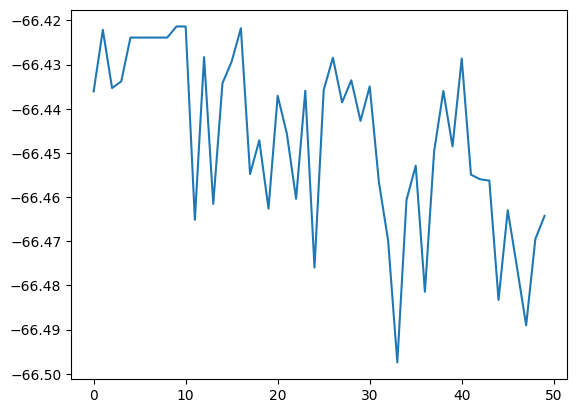

In [29]:
plt.plot(history[0].logdensity)

In [ ]:
# Import ChainConsumer
from chainconsumer import Chain, ChainConsumer, Truth

# Extract positions from history and convert to DataFrame
RWState = history[0]
positions = RWState.position
df = pd.DataFrame(positions)
df.columns = ['$M_{MN}$ [M$_\\odot$]', '$M_{NFW}$ [M$_\\odot$]', '$M_{Plummer}$ [M$_\\odot$]', '$a_{MN}$ [kpc]', '$a_{Plummer}$ [kpc]', '$r_s$ [kpc]', '$t_{end}$ [Gyr]']

# Remove burn-in (first 1000 samples)
df_burned = df.iloc[:].reset_index(drop=True)

# Define parameter names with LaTeX formatting
param_names = ['$t_{end}$ [Gyr]', '$M_{Plummer}$ [M$_\\odot$]', '$a_{Plummer}$ [kpc]', 
               '$M_{NFW}$ [M$_\\odot$]', '$r_s$ [kpc]', '$M_{MN}$ [M$_\\odot$]', '$a_{MN}$ [kpc]']
params_names = df.columns

# Create Chain object
chain = Chain(samples=df_burned, name="MCMC Posterior")

# Create ChainConsumer object
c = ChainConsumer()
c.add_chain(chain)

# Add true values if you want to compare
true_values_dict = {
    '$t_{end}$ [Gyr]': 3.0,
    '$M_{Plummer}$ [M$_\\odot$]': 10**4.05,
    '$a_{Plummer}$ [kpc]': 8.0 * 1e-3,
    '$M_{NFW}$ [M$_\\odot$]': 4.3683325e11,
    '$r_s$ [kpc]': 16.0,
    '$M_{MN}$ [M$_\\odot$]': 68_193_902_782.346756,
    '$a_{MN}$ [kpc]': 3.0
}

# Add truth values
truth = Truth(location=true_values_dict, name="True Parameters")
c.add_truth(truth)

# Create corner plot
fig = c.plotter.plot()
plt.show()

# Print summary statistics
print("MCMC Summary (after burn-in):")
print(f"Number of samples: {len(df_burned)}")
print(f"Parameter means:")
for i, param in enumerate(param_names):
    print(f"  {param}: {df_burned.iloc[:, i].mean():.6e}")

print(f"\nParameter std deviations:")
for i, param in enumerate(param_names):
    print(f"  {param}: {df_burned.iloc[:, i].std():.6e}")

ValueError: Too many bins for data range. Cannot create 2000 finite-sized bins.